# Construction Project Status Classification  
**MLOps Project — Google Colab Phase**

Dataset: Data Proyek Konstruksi (`dataset_kontruksi.xlsx`)  

Target: `Status` — klasifikasi status proyek menjadi:  
- **Gagal (0)**  
- **Sedang (1)**  
- **Sukses (2)**  

Berdasarkan beberapa fitur proyek seperti:  
- Anggaran Proyek  
- Nilai Kontrak Konsultan  
- Durasi Proyek  
- Jumlah Proyek  
- Progress Fisik  
- Lokasi  
- Jenis Layanan  

---

Pipeline Colab:

1. Setup & Install Libraries  
2. Import Libraries  
3. Upload & Load Dataset  
4. Exploratory Data Analysis (EDA)  
5. Data Preprocessing  
   - Missing Value Handling  
   - Label Encoding  
   - Feature Scaling  
6. Train-Test Split  
7. Baseline Modelling (Random Forest)  
8. Hyperparameter Tuning (GridSearchCV)  
9. Model Evaluation  
10. Export Model & Save Artifacts  

SETUP & INSTAL DEPENDENCIES

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn joblib -q

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

LOAD DATASET

In [3]:
from google.colab import files

uploaded = files.upload()

Saving dataset_kontruksi.xlsx to dataset_kontruksi.xlsx


In [4]:
df = pd.read_excel("dataset_kontruksi.xlsx")

In [5]:
df.head()

,ID_Proyek,Nama_Proyek,Lokasi,Jenis_Layanan,Anggaran_Proyek_IDR,Nilai_Kontrak_Konsultan_IDR,Status,Durasi_Bulan,Jumlah_Proyek,Progress_Fisik
0,PRJ-0001,Detail Engineering Design Pembangunan Gedung S...,Riau,Detail Engineering Design,224000000000,11031797972,Kontrak Baru,12,2,0.00
1,PRJ-0002,Detail Engineering Design Pembangunan Rumah Sa...,Jawa Timur,Detail Engineering Design,128000000000,5068693150,Kontrak Baru,16,2,0.00
2,PRJ-0003,Perencanaan Arsitektur Pembangunan Sistem Irig...,Sulawesi Utara,Perencanaan Arsitektur,16000000000,503548736,Berjalan,13,1,0.77
3,PRJ-0004,Masterplan & Tata Kota Pembangunan Sistem Irig...,Sulawesi Utara,Masterplan & Tata Kota,29000000000,793029250,Kontrak Baru,4,4,0.00
4,PRJ-0005,Audit Forensik Struktur Pembangunan Jalan Tol ...,Sulawesi Utara,Audit Forensik Struktur,5000000000,280640146,Kontrak Baru,8,5,0.00


EXPLORATORY DATA ANALYSIS(EDA)

In [6]:
print('=== Dataset Info ===')
df.info()

print('\n=== Missing Values ===')
missing = df.isnull().sum()
print(missing[missing > 0])

=== Dataset Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   ID_Proyek                    2000 non-null   object 
 1   Nama_Proyek                  2000 non-null   object 
 2   Lokasi                       2000 non-null   object 
 3   Jenis_Layanan                2000 non-null   object 
 4   Anggaran_Proyek_IDR          2000 non-null   int64  
 5   Nilai_Kontrak_Konsultan_IDR  2000 non-null   int64  
 6   Status                       2000 non-null   object 
 7   Durasi_Bulan                 2000 non-null   int64  
 8   Jumlah_Proyek                2000 non-null   int64  
 9   Progress_Fisik               2000 non-null   float64
dtypes: float64(1), int64(4), object(5)
memory usage: 156.4+ KB

=== Missing Values ===
Series([], dtype: int64)


In [8]:
print('=== Statistik Anggaran Proyek ===')
print(df['Anggaran_Proyek_IDR'].describe())

print('\n=== Statistik Nilai Kontrak ===')
print(df['Nilai_Kontrak_Konsultan_IDR'].describe())

=== Statistik Anggaran Proyek ===
count    2.000000e+03
mean     5.671750e+10
std      6.453259e+10
min      1.000000e+09
25%      1.300000e+10
50%      3.200000e+10
75%      6.525000e+10
max      2.490000e+11
Name: Anggaran_Proyek_IDR, dtype: float64

=== Statistik Nilai Kontrak ===
count    2.000000e+03
mean     2.254904e+09
std      2.762253e+09
min      2.034183e+07
25%      4.864562e+08
50%      1.225927e+09
75%      2.528354e+09
max      1.445217e+10
Name: Nilai_Kontrak_Konsultan_IDR, dtype: float64


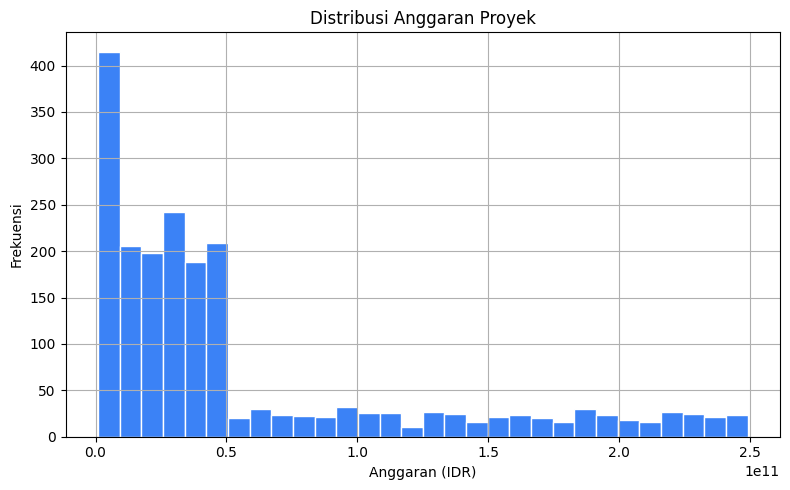

In [9]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(8, 5))

df['Anggaran_Proyek_IDR'].dropna().hist(
    bins=30, ax=ax, color='#3B82F6', edgecolor='white'
)

ax.set_title('Distribusi Anggaran Proyek')
ax.set_xlabel('Anggaran (IDR)')
ax.set_ylabel('Frekuensi')

plt.tight_layout()
plt.savefig('eda_anggaran.png', dpi=150, bbox_inches='tight')
plt.show()

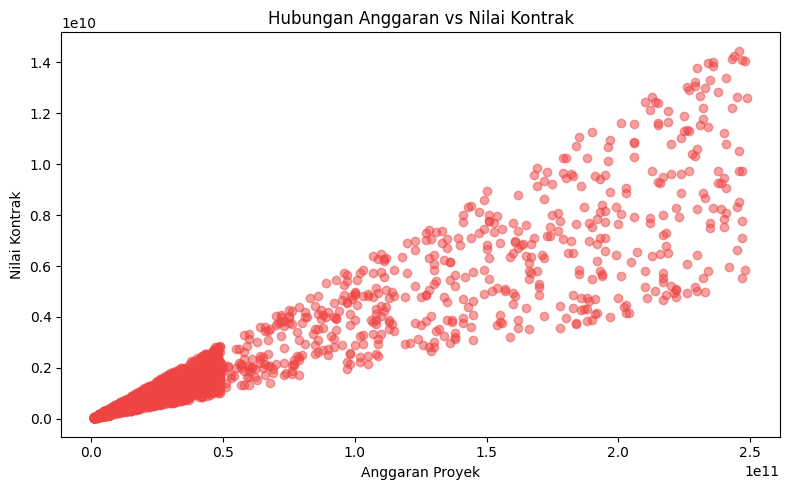

In [10]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    df['Anggaran_Proyek_IDR'],
    df['Nilai_Kontrak_Konsultan_IDR'],
    alpha=0.5,
    color='#EF4444'
)

ax.set_title('Hubungan Anggaran vs Nilai Kontrak')
ax.set_xlabel('Anggaran Proyek')
ax.set_ylabel('Nilai Kontrak')

plt.tight_layout()
plt.savefig('eda_anggaran_kontrak.png', dpi=150, bbox_inches='tight')
plt.show()

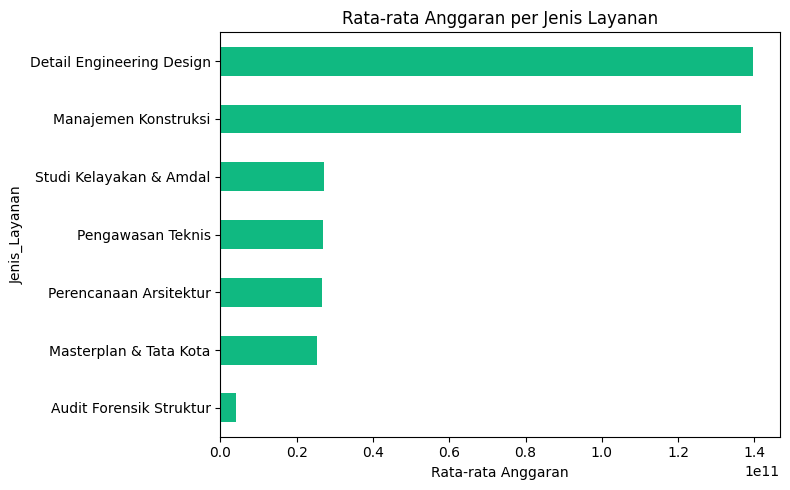

In [11]:
fig, ax = plt.subplots(figsize=(8, 5))

df.groupby('Jenis_Layanan')['Anggaran_Proyek_IDR'].mean().sort_values().plot(
    kind='barh', ax=ax, color='#10B981'
)

ax.set_title('Rata-rata Anggaran per Jenis Layanan')
ax.set_xlabel('Rata-rata Anggaran')

plt.tight_layout()
plt.savefig('eda_jenis_layanan.png', dpi=150, bbox_inches='tight')
plt.show()

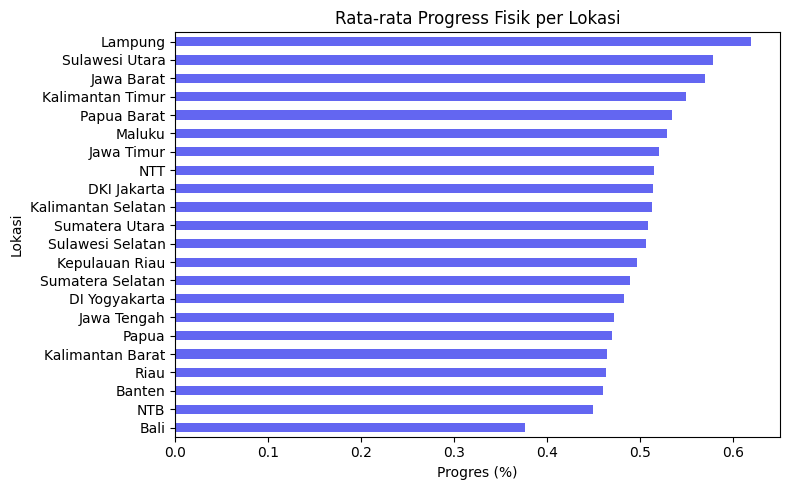

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))

df.groupby('Lokasi')['Progress_Fisik'].mean().sort_values().plot(
    kind='barh', ax=ax, color='#6366F1'
)

ax.set_title('Rata-rata Progress Fisik per Lokasi')
ax.set_xlabel('Progres (%)')

plt.tight_layout()
plt.savefig('eda_lokasi_progres.png', dpi=150, bbox_inches='tight')
plt.show()

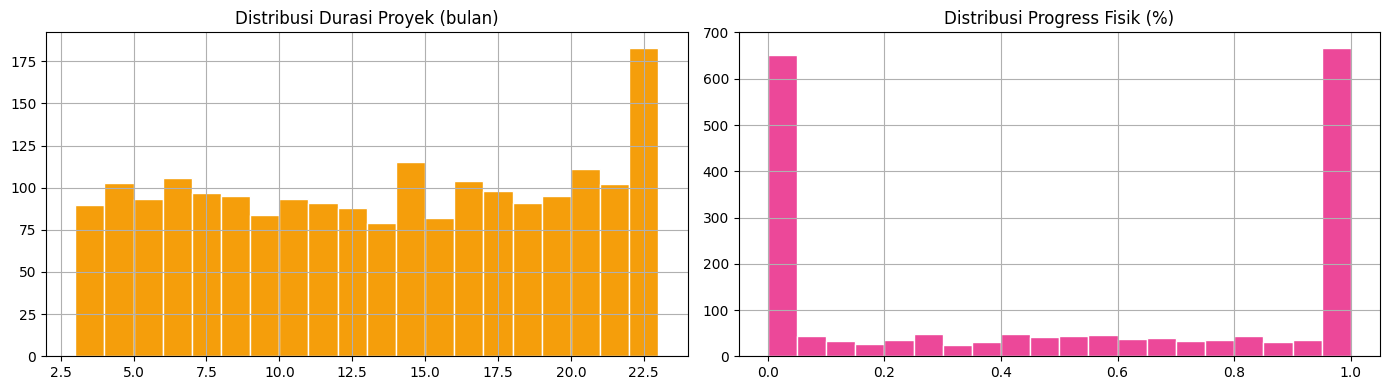

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['Durasi_Bulan'].hist(bins=20, ax=axes[0], color='#F59E0B', edgecolor='white')
axes[0].set_title('Distribusi Durasi Proyek (bulan)')

df['Progress_Fisik'].hist(bins=20, ax=axes[1], color='#EC4899', edgecolor='white')
axes[1].set_title('Distribusi Progress Fisik (%)')

plt.tight_layout()
plt.show()

PREPROCESSING

In [18]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
import pandas as pd
import os

def preprocess(df):
    df = df.copy()

    # Step 1: Drop ID & Nama (tidak dipakai untuk model)
    drop_cols = ["ID_Proyek", "Nama_Proyek"]
    df.drop(columns=[c for c in drop_cols if c in df.columns], inplace=True)

    print(f'[INFO] Setelah drop ID/Nama     : {df.shape}')

    # Step 2: Handle missing values
    df.dropna(inplace=True)
    print(f'[INFO] Setelah handle missing   : {df.shape}')

    # Step 3: Encode target (Status)
    # jika Status masih teks (misal: "Sukses", "Gagal")
    if "Status" in df.columns:
        le_target = LabelEncoder()
        df["Status"] = le_target.fit_transform(df["Status"])
        print(f'[INFO] Status encoded')

    # Step 4: Encode kolom kategorikal
    cat_cols = ["Lokasi", "Jenis_Layanan"]

    le_dict = {}
    for col in cat_cols:
        if col in df.columns:
            le = LabelEncoder()
            df[col] = le.fit_transform(df[col].astype(str))
            le_dict[col] = le

    print(f'[INFO] Categorical encoded')

    # Step 5: Feature scaling (numerik)
    num_cols = [
        "Anggaran_Proyek_IDR",
        "Nilai_Kontrak",
        "Durasi_Bulan",
        "Jumlah_Proyek",
        "Progress_Fisik"
    ]

    scaler = StandardScaler()
    existing_num_cols = [c for c in num_cols if c in df.columns]

    if existing_num_cols:
        df[existing_num_cols] = scaler.fit_transform(df[existing_num_cols])

    print(f'[INFO] Scaling selesai         : {df.shape}')

    return df, le_dict, scaler

In [19]:
df_processed, encoders, scaler = preprocess(df)

print('\n=== Distribusi Status ===')
print(df_processed['Status'].value_counts())
print(df_processed['Status'].value_counts(normalize=True).map('{:.1%}'.format))

df_processed.head()

[INFO] Setelah drop ID/Nama     : (2000, 8)
[INFO] Setelah handle missing   : (2000, 8)
[INFO] Status encoded
[INFO] Categorical encoded
[INFO] Scaling selesai         : (2000, 8)

=== Distribusi Status ===
Status
0    681
2    667
1    652
Name: count, dtype: int64
Status
0    34.1%
2    33.4%
1    32.6%
Name: proportion, dtype: object


,Lokasi,Jenis_Layanan,Anggaran_Proyek_IDR,Nilai_Kontrak_Konsultan_IDR,Status,Durasi_Bulan,Jumlah_Proyek,Progress_Fisik
0,17,1,2.592866,11031797972,1,-0.171134,-0.720947,-1.165028
1,6,1,1.104873,5068693150,1,0.485812,-0.720947,-1.165028
2,19,5,-0.631118,503548736,0,-0.006898,-1.414499,0.615795
3,19,3,-0.429619,793029250,1,-1.485027,0.666157,-1.165028
4,19,0,-0.801617,280640146,1,-0.828081,1.359709,-1.165028


In [20]:
os.makedirs('data_konstruksi_preprocessed', exist_ok=True)

df_processed.to_csv(
    'data_konstruksi_preprocessed/preprocessed.csv',
    index=False
)

print('✓ Saved: data_konstruksi_preprocessed/preprocessed.csv')
print(f'  Shape   : {df_processed.shape}')
print(f'  Columns : {list(df_processed.columns)}')

✓ Saved: data_konstruksi_preprocessed/preprocessed.csv
  Shape   : (2000, 8)
  Columns : ['Lokasi', 'Jenis_Layanan', 'Anggaran_Proyek_IDR', 'Nilai_Kontrak_Konsultan_IDR', 'Status', 'Durasi_Bulan', 'Jumlah_Proyek', 'Progress_Fisik']


BASELINE MODELLING

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, ConfusionMatrixDisplay, RocCurveDisplay
)

# TARGET: Status proyek (0 = Gagal, 1 = Sukses)
X = df_processed.drop(columns=['Status'])
y = df_processed['Status']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train size : {X_train.shape}')
print(f'Test size  : {X_test.shape}')

Train size : (1600, 7)
Test size  : (400, 7)


In [23]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

y_pred  = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

In [29]:
print('=== Classification Report (Baseline) ===')

print(classification_report(
    y_test,
    y_pred,
    labels=[0, 1, 2],
    target_names=['Gagal', 'Sedang', 'Sukses']
))

=== Classification Report (Baseline) ===
              precision    recall  f1-score   support

       Gagal       1.00      1.00      1.00       136
      Sedang       1.00      1.00      1.00       131
      Sukses       1.00      1.00      1.00       133

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



HYPERPARAMETER TUNING

In [34]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

cv_strategy = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

grid_search = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=param_grid,
    cv=cv_strategy,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=1
)

print('Running GridSearchCV... (estimasi beberapa menit)')
grid_search.fit(X_train, y_train)

print(f'\n✓ Best Params  : {grid_search.best_params_}')
print(f'✓ Best F1 (CV) : {grid_search.best_score_:.4f}')

Running GridSearchCV... (estimasi beberapa menit)
Fitting 5 folds for each of 36 candidates, totalling 180 fits

✓ Best Params  : {'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
✓ Best F1 (CV) : 1.0000


In [35]:
best_model = grid_search.best_estimator_

y_pred_tuned = best_model.predict(X_test)
y_proba_tuned = best_model.predict_proba(X_test)[:, 1]

In [42]:
from sklearn.metrics import roc_auc_score, classification_report

print('=== Classification Report (Tuned Model) ===')

print(classification_report(
    y_test,
    y_pred_tuned,
    target_names=['Gagal', 'Sedang', 'Sukses']
))

y_proba_tuned = best_model.predict_proba(X_test)

print(f'\nAUC-ROC : {roc_auc_score(y_test, y_proba_tuned, multi_class="ovr"):.4f}')

=== Classification Report (Tuned Model) ===
              precision    recall  f1-score   support

       Gagal       1.00      1.00      1.00       136
      Sedang       1.00      1.00      1.00       131
      Sukses       1.00      1.00      1.00       133

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400


AUC-ROC : 1.0000


In [45]:
from sklearn.metrics import (
    accuracy_score, f1_score,
    precision_score, recall_score,
    roc_auc_score
)
import pandas as pd

# WAJIB: pastikan probability FULL (bukan [:,1])
y_proba = model.predict_proba(X_test)
y_proba_tuned = best_model.predict_proba(X_test)

metrics = {
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, y_pred_tuned)
    ],

    'F1 Score': [
        f1_score(y_test, y_pred, average='weighted'),
        f1_score(y_test, y_pred_tuned, average='weighted')
    ],

    'Precision': [
        precision_score(y_test, y_pred, average='weighted'),
        precision_score(y_test, y_pred_tuned, average='weighted')
    ],

    'Recall': [
        recall_score(y_test, y_pred, average='weighted'),
        recall_score(y_test, y_pred_tuned, average='weighted')
    ],

    'AUC-ROC': [
        roc_auc_score(y_test, y_proba, multi_class='ovr'),
        roc_auc_score(y_test, y_proba_tuned, multi_class='ovr')
    ]
}

df_compare = pd.DataFrame(metrics, index=['Baseline', 'Tuned']).T
print(df_compare)

           Baseline  Tuned
Accuracy        1.0    1.0
F1 Score        1.0    1.0
Precision       1.0    1.0
Recall          1.0    1.0
AUC-ROC         1.0    1.0


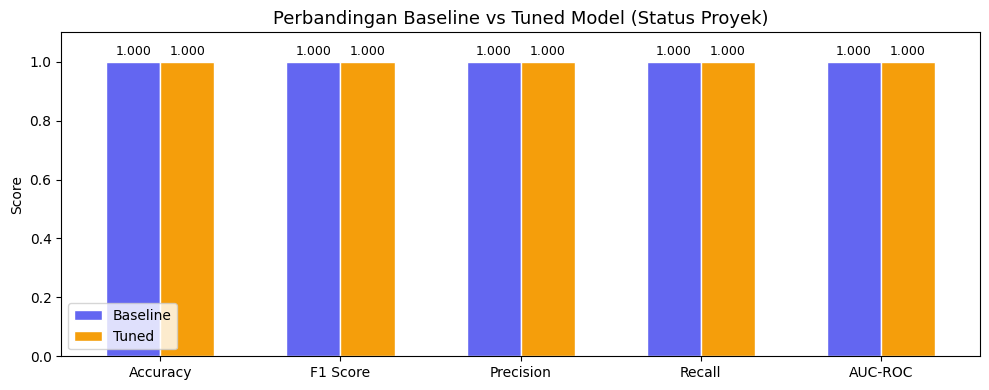

In [46]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 4))

df_compare.plot(
    kind='bar',
    ax=ax,
    color=['#6366F1', '#F59E0B'],
    edgecolor='white',
    width=0.6
)

ax.set_ylim(0, 1.1)
ax.set_title('Perbandingan Baseline vs Tuned Model (Status Proyek)', fontsize=13)
ax.set_ylabel('Score')
ax.legend(['Baseline', 'Tuned'])
ax.tick_params(axis='x', rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.3f', padding=3, fontsize=9)

plt.tight_layout()
plt.savefig('comparison.png', dpi=150, bbox_inches='tight')
plt.show()

EXPORT & DOWNLOAD

In [47]:
import joblib
import os
from google.colab import files

In [50]:
joblib.dump(model, 'konstruksi_model_baseline.pkl')
joblib.dump(best_model, 'konstruksi_model_tuned.pkl')

df_compare.to_csv('model_metrics.csv', index=True)

print('✓ konstruksi_model_baseline.pkl')
print('✓ konstruksi_model_tuned.pkl')
print('✓ model_metrics.csv')

✓ konstruksi_model_baseline.pkl
✓ konstruksi_model_tuned.pkl
✓ model_metrics.csv


In [49]:
os.makedirs('data_konstruksi_preprocessed', exist_ok=True)

df_processed.to_csv(
    'data_konstruksi_preprocessed/preprocessed.csv',
    index=False
)

print('✓ preprocessed dataset saved')

✓ preprocessed dataset saved


In [52]:
files_list = [
    'data_konstruksi_preprocessed/preprocessed.csv',
    'konstruksi_model_baseline.pkl',
    'konstruksi_model_tuned.pkl',
    'model_metrics.csv',
    'eda_anggaran.png',
    'eda_anggaran_kontrak.png',
    'eda_jenis_layanan.png',
    'eda_lokasi_progres.png',
    'feature_importance.png',
    'comparison.png',
]

In [53]:
for fname in files_list:
    if os.path.exists(fname):
        files.download(fname)
        print(f'✓ Downloaded: {fname}')
    else:
        print(f'✗ Not found : {fname}')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded: data_konstruksi_preprocessed/preprocessed.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✓ Downloaded: eda_lokasi_progres.png
✗ Not found : feature_importance.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded: comparison.png
